# Amazon Sales: Exploratory Data Analysis

_**TODO:** Insert dataset overview here..._

## Load Dataset and Dependencies

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("data/amazon.csv")
df_raw.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Initial Data Inspection

In [3]:
rows, cols = df_raw.shape

print("Number of rows:", rows)
print("Number of columns:", cols)

Number of rows: 1465
Number of columns: 16


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## Data Cleaning

### Issues Identified

**Duplicates**
- There are no duplicated rows.

**Irrelevant Columns/Features**
- `product_id`, `user_id`, `review_id` are not needed because they only serve as identifiers.
- `user_name` should not be included since this is personally identifiable information (PII).
- `about_product`, `review_title`, and `review_content` are unstructured text features and would not be needed for EDA.
    - **NOTE:** These features could be used in the modeling stage if preprocessing is applied to extract embeddings.
- `img_link` and `product_link` can be excluded as they are just URLs pointing to the source of data.

**Data Type Issues**
- `discounted_price`, `actual_price`, `discount_percentage`, `rating`, and `rating_count` are currently stored as `object` and should be converted to `float` dtype.

**Formatting Issues**
- `category` values are too granular due to their deeply nested hierarchical structure, leading to high cardinality. It would be better to extract their general category label and reformat the values to become more readable.
- `discounted_price`, `actual_price`, and `discount_percentage` have unnecessary symbols (e.g., '₹' and '%') and could be the cause why these columns are stored as `object` dtype.
- `discount_percentage` should be in decimal format: `(64% -> 0.64)`

**Incorrect/Erroneous Values**
- `rating` has one record containing `|`.

**Missing Values**
- `rating_count` - 2 missing
- `rating` - 1 missing (Formatted as empty string instead of `NaN`, due to the incorrect value mentioned above)

**Data Range Issues**
- There is no out of range data across each numerical column.

**Outliers**
- Using the IQR method, outliers have been identified in the following columns:
    - `discounted_price` - 217
    - `actual_price` - 213
    - `rating` - 74
    - `rating_count` - 141

In [5]:
# Check for duplicate records
num_dups = df_raw.duplicated().sum()
print("Number of duplicate records:", num_dups)

Number of duplicate records: 0


In [6]:
# Check for incorrect data types
df_raw.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

In [7]:
# Check formatting issues on the following columns
df_raw[["discounted_price", "actual_price", "discount_percentage"]].head()

,discounted_price,actual_price,discount_percentage
0,₹399,"₹1,099",64%
1,₹199,₹349,43%
2,₹199,"₹1,899",90%
3,₹329,₹699,53%
4,₹154,₹399,61%


In [8]:
# Check for missing values
print("Missing values per column:")
df_raw.isna().sum()

Missing values per column:


product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [9]:
# Check for incorrect/erroneous values (only included relevant columns to the task)
# Uncomment one at a time when checking

# df_raw["category"].unique()
# df_raw["discounted_price"].unique().tolist()
# df_raw["actual_price"].unique().tolist()
# df_raw["discount_percentage"].unique().tolist()
# df_raw["rating_count"].unique().tolist()
df_raw["rating"].unique().tolist()

['4.2',
 '4.0',
 '3.9',
 '4.1',
 '4.3',
 '4.4',
 '4.5',
 '3.7',
 '3.3',
 '3.6',
 '3.4',
 '3.8',
 '3.5',
 '4.6',
 '3.2',
 '5.0',
 '4.7',
 '3.0',
 '2.8',
 '4',
 '3.1',
 '4.8',
 '2.3',
 '|',
 '2',
 '3',
 '2.6',
 '2.9']

In [10]:
# Check structure of `category` to guide in creating broader classes
df_raw["category"].unique().tolist()

['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters',
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables',
 'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
 'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
 'Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions',
 'Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts',
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACables',
 'Electronics|HomeAudio|Accessories|SpeakerAccessories|Mounts',
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables',
 'Electronics|HomeTheater,TV&Video|Projectors',
 'Electronics|HomeAudio|Accessories|Adapters',
 'Electronics|HomeTheater,TV&Video|SatelliteEquipment|SatelliteReceivers',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|DVICables',
 'Electronics|H

### Fixing the Issues

In [11]:
# Create copy to store cleaned data
df_clean = df_raw.copy()

# Drop irrelevant columns
cols_to_drop = ["product_id", "user_id", "review_id", 
                "user_name", "about_product", "review_title", 
                "review_content", "img_link", "product_link"]

df_clean.drop(columns=cols_to_drop, inplace=True)

# Convert columns to appropriate data types
num_cols = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]

# Remove unnecessary characters (particularly currency symbols and commas)
for col in num_cols:
    df_clean[col] = df_clean[col].str.replace(r"[^\d.]", "", regex=True) # This regex only keeps digits and dots

# Convert columns to numeric
df_clean[num_cols] = df_clean[num_cols].apply(pd.to_numeric, errors="coerce")

# Convert `discount_percentage` to range 0-1 (64 -> 0.64)
df_clean["discount_percentage"] = df_clean["discount_percentage"] / 100

# Consolidate original categories into generalizable classes
df_clean["category"] = df_clean["category"].str.split("|").str[0]

# Reformat category names to be more readable
df_clean["category"] = df_clean["category"].str.replace("&", " & ")

# Convert to category dtype
df_clean["category"] = df_clean["category"].astype("category")

# Inspect remapped categories
print(f"Number of categories: {df_clean["category"].nunique()}")
df_clean["category"].value_counts()

Number of categories: 9


category
Electronics                526
Computers & Accessories    453
Home & Kitchen             448
OfficeProducts              31
HomeImprovement              2
MusicalInstruments           2
Car & Motorbike              1
Health & PersonalCare        1
Toys & Games                 1
Name: count, dtype: int64

In [12]:
df_clean.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers & Accessories,399.0,1099.0,0.64,4.2,24269.0
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,199.0,349.0,0.43,4.0,43994.0
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers & Accessories,199.0,1899.0,0.90,3.9,7928.0
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers & Accessories,329.0,699.0,0.53,4.2,94363.0
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers & Accessories,154.0,399.0,0.61,4.2,16905.0


In [13]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   product_name         1465 non-null   object  
 1   category             1465 non-null   category
 2   discounted_price     1465 non-null   float64 
 3   actual_price         1465 non-null   float64 
 4   discount_percentage  1465 non-null   float64 
 5   rating               1464 non-null   float64 
 6   rating_count         1463 non-null   float64 
dtypes: category(1), float64(5), object(1)
memory usage: 70.6+ KB


**NOTE:** After cleaning the numerical columns, an additional missing value was found in the `rating` column.

In [14]:
df_clean.isna().sum()

product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
dtype: int64

In [15]:
# Check if data is in correct range
df_clean.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,0.476915,4.096585,18295.541353
std,6944.304394,10874.826864,0.216359,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.320000,4.000000,1186.000000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4295.000000,0.630000,4.300000,17336.500000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


Before fixing missing values, we must first investigate the data further before deciding on a solution.

In [16]:
# Inspect rows with missing values
df_clean[df_clean.isna().any(axis=1)].head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
282,Amazon Brand - Solimo 65W Fast Charging Braide...,Computers & Accessories,199.0,999.0,0.80,3.0,NaN
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers & Accessories,249.0,999.0,0.75,5.0,NaN
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home & Kitchen,2099.0,2499.0,0.16,NaN,992.0


Since `rating` will be the prediction target, and there is only a single row affected, missing values from this column can be dropped to ensure data integrity of the ground truth.

In [17]:
df_clean.dropna(subset="rating", inplace=True)

df_clean.isna().sum()

product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
dtype: int64

For handling missing values in `rating_count`, **imputation** will be used to fill in nulls with a substitute value (mean or median), and preserves data size by avoiding dropping rows that could still hold predictive power. To determine which method to use, we must first investigate the distribution of the data since mean imputation is sensitive to skewed data.  

In [18]:
df_clean["rating_count"].describe()

count      1462.000000
mean      18307.376881
std       42766.096572
min           2.000000
25%        1191.500000
50%        5179.000000
75%       17342.250000
max      426973.000000
Name: rating_count, dtype: float64

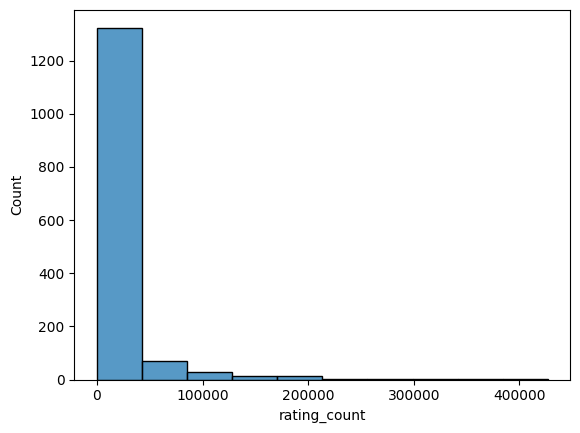

In [19]:
sns.histplot(data=df_clean, x="rating_count", bins=10)
plt.show()

Based on both descriptive statistics and visualization, the `rating_count` column is right-skewed and it would be preferred to use the **median** for imputing missing values since it is less sensitive to outliers compared to using the mean.

In [20]:
rating_count_median = df_clean["rating_count"].median()

df_clean["rating_count"] = df_clean["rating_count"].fillna(rating_count_median)

df_clean.isna().sum()

product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
dtype: int64

In [21]:
# Check for outliers (Use IQR method)
def find_outliers(df, col):
    # Calculate first and third quartiles (25th and 75th percentiles)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # Calculate IQR
    iqr = q3 - q1

    # Calculate lower and upper bounds
    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)

    # Log results
    print("Column:", col)
    print("Lower bound:", lower)
    print("Upper bound:", upper)

    # Identify outliers, which are the values outside the bounds
    return df[(df[col] < lower) | (df[col] > upper)]


# Find outliers in all numeric columns
# `num_cols` was already defined earlier
for col in num_cols:
    outliers = find_outliers(df_clean, col)
    count_outliers = len(outliers)
    print(f"Count of outliers: {count_outliers}\n")

Column: discounted_price
Lower bound: -2189.125
Upper bound: 4511.875
Count of outliers: 217

Column: actual_price
Lower bound: -4455.625
Upper bound: 9559.375
Count of outliers: 213

Column: discount_percentage
Lower bound: -0.14499999999999996
Upper bound: 1.095
Count of outliers: 0

Column: rating
Lower bound: 3.5500000000000003
Upper bound: 4.75
Count of outliers: 74

Column: rating_count
Lower bound: -23014.875
Upper bound: 41538.125
Count of outliers: 141



Since there are several outliers across three of the numerical columns, we must first investigate these instances to inform how to handle them properly.

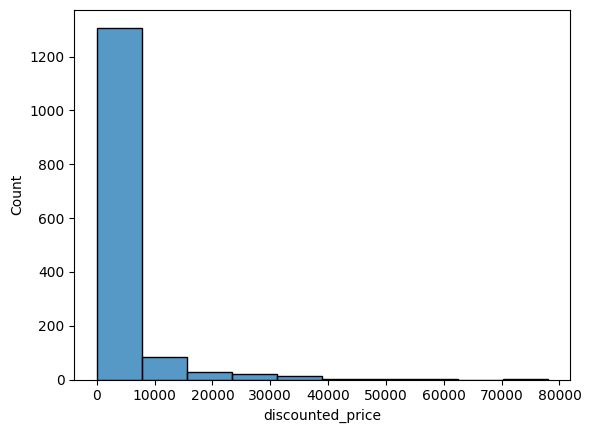

In [22]:
sns.histplot(data=df_clean, x="discounted_price", bins=10)
plt.show()

In [23]:
find_outliers(df_clean, "discounted_price")

Column: discounted_price
Lower bound: -2189.125
Upper bound: 4511.875


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
16,MI 80 cm (32 inches) 5A Series HD Ready Smart ...,Electronics,13999.0,24999.0,0.44,4.2,32840.0
19,LG 80 cm (32 inches) HD Ready Smart LED TV 32L...,Electronics,13490.0,21990.0,0.39,4.3,11976.0
22,Samsung 80 cm (32 Inches) Wondertainment Serie...,Electronics,13490.0,22900.0,0.41,4.3,16299.0
24,Acer 80 cm (32 inches) I Series HD Ready Andro...,Electronics,11499.0,19990.0,0.42,4.3,4703.0
26,OnePlus 80 cm (32 inches) Y Series HD Ready LE...,Electronics,14999.0,19999.0,0.25,4.2,34899.0
...,...,...,...,...,...,...,...
1428,"Sujata Dynamix, Mixer Grinder, 900 Watts, 3 Ja...",Home & Kitchen,6120.0,8073.0,0.24,4.6,2751.0
1430,"Mi Robot Vacuum-Mop P, Best-in-class Laser Nav...",Home & Kitchen,18999.0,29999.0,0.37,4.1,2536.0
1432,AGARO Royal Stand 1000W Mixer with 5L SS Bowl ...,Home & Kitchen,5999.0,11495.0,0.48,4.3,534.0
1437,"Karcher WD3 EU Wet and Dry Vacuum Cleaner, 100...",Home & Kitchen,6199.0,10999.0,0.44,4.2,10429.0


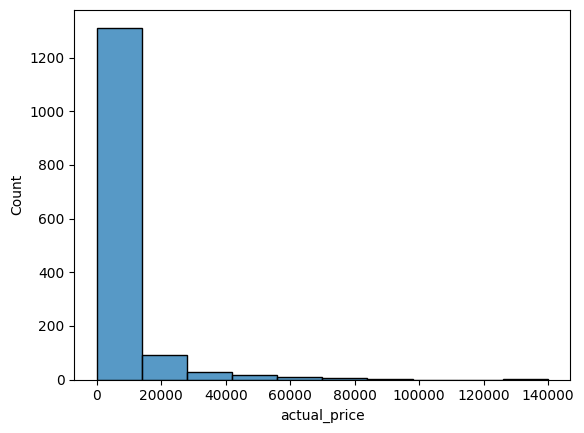

In [24]:
sns.histplot(data=df_clean, x="actual_price", bins=10)
plt.show()

In [25]:
find_outliers(df_clean, "actual_price")

Column: actual_price
Lower bound: -4455.625
Upper bound: 9559.375


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
16,MI 80 cm (32 inches) 5A Series HD Ready Smart ...,Electronics,13999.0,24999.0,0.44,4.2,32840.0
19,LG 80 cm (32 inches) HD Ready Smart LED TV 32L...,Electronics,13490.0,21990.0,0.39,4.3,11976.0
22,Samsung 80 cm (32 Inches) Wondertainment Serie...,Electronics,13490.0,22900.0,0.41,4.3,16299.0
24,Acer 80 cm (32 inches) I Series HD Ready Andro...,Electronics,11499.0,19990.0,0.42,4.3,4703.0
26,OnePlus 80 cm (32 inches) Y Series HD Ready LE...,Electronics,14999.0,19999.0,0.25,4.2,34899.0
...,...,...,...,...,...,...,...
1416,Aqua d pure Active Copper 12-L RO+UV Water Fil...,Home & Kitchen,4999.0,24999.0,0.80,4.5,287.0
1430,"Mi Robot Vacuum-Mop P, Best-in-class Laser Nav...",Home & Kitchen,18999.0,29999.0,0.37,4.1,2536.0
1432,AGARO Royal Stand 1000W Mixer with 5L SS Bowl ...,Home & Kitchen,5999.0,11495.0,0.48,4.3,534.0
1437,"Karcher WD3 EU Wet and Dry Vacuum Cleaner, 100...",Home & Kitchen,6199.0,10999.0,0.44,4.2,10429.0


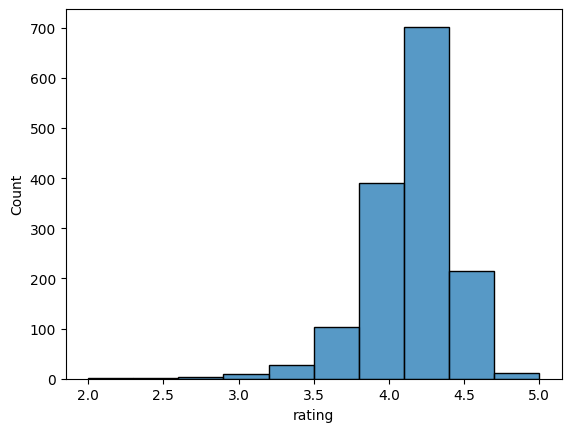

In [26]:
sns.histplot(data=df_clean, x="rating", bins=10)
plt.show()

In [27]:
find_outliers(df_clean, "rating")

Column: rating
Lower bound: 3.5500000000000003
Upper bound: 4.75


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
45,Wecool Nylon Braided Multifunction Fast Chargi...,Computers & Accessories,333.0,999.0,0.67,3.3,9792.0
82,SKYWALL 81.28 cm (32 inches) HD Ready Smart LE...,Electronics,7299.0,19125.0,0.62,3.4,902.0
117,King Shine Multi Retractable 3.0A Fast Charger...,Computers & Accessories,347.0,999.0,0.65,3.5,1121.0
142,LRIPL Mi Remote Control with Netflix & Prime V...,Electronics,655.0,1099.0,0.40,3.2,285.0
154,GENERIC Ultra-Mini Bluetooth CSR 4.0 USB Dongl...,Computers & Accessories,249.0,399.0,0.38,3.4,4642.0
...,...,...,...,...,...,...,...
1446,Hilton Quartz Heater 400/800-Watt ISI 2 Rods M...,Home & Kitchen,1149.0,1899.0,0.39,3.5,24.0
1449,IONIX Tap filter Multilayer | Activated Carbon...,Home & Kitchen,199.0,699.0,0.72,2.9,159.0
1454,akiara - Makes life easy Mini Sewing Machine f...,Home & Kitchen,1563.0,3098.0,0.50,3.5,2283.0
1456,"4 in 1 Handheld Electric Vegetable Cutter Set,...",Home & Kitchen,498.0,1200.0,0.59,3.2,113.0


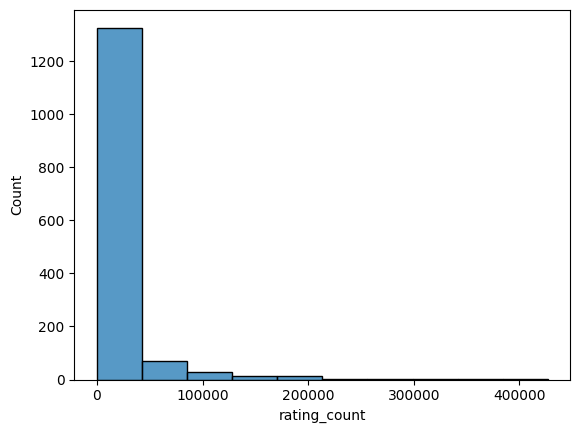

In [28]:
sns.histplot(data=df_clean, x="rating_count", bins=10)
plt.show()

In [29]:
find_outliers(df_clean, "rating_count")

Column: rating_count
Lower bound: -23014.875
Upper bound: 41538.125


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,199.0,349.0,0.43,4.0,43994.0
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers & Accessories,329.0,699.0,0.53,4.2,94363.0
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...",Computers & Accessories,499.0,999.0,0.50,4.2,179691.0
9,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,199.0,299.0,0.33,4.0,43994.0
11,boAt Rugged v3 Extra Tough Unbreakable Braided...,Computers & Accessories,299.0,799.0,0.63,4.2,94363.0
...,...,...,...,...,...,...,...
1032,Pigeon by Stovekraft Cruise 1800 watt Inductio...,Home & Kitchen,1699.0,3193.0,0.47,3.8,54032.0
1045,Lifelong LLMG23 Power Pro 500-Watt Mixer Grind...,Home & Kitchen,1299.0,3500.0,0.63,3.8,44050.0
1077,Bajaj DX-7 1000W Dry Iron with Advance Solepla...,Home & Kitchen,775.0,875.0,0.11,4.2,46647.0
1130,Prestige Iris 750 Watt Mixer Grinder with 3 St...,Home & Kitchen,3249.0,6295.0,0.48,3.9,43070.0


Based on both statistical and visual investigation, all data points that were identified as outliers did not demonstrate any erroenous values nor possible data entry issues. The probable cause of these anomalies could be that the majority of values are concentrated on a narrow range (as seen in the histograms). Therefore, the verdict is to **keep all outliers** as they contain genuine values and removing them would just cause significant data loss.

In [30]:
# Inspect cleaned data
df_clean.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers & Accessories,399.0,1099.0,0.64,4.2,24269.0
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,199.0,349.0,0.43,4.0,43994.0
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers & Accessories,199.0,1899.0,0.90,3.9,7928.0
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers & Accessories,329.0,699.0,0.53,4.2,94363.0
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers & Accessories,154.0,399.0,0.61,4.2,16905.0


In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 0 to 1464
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   product_name         1464 non-null   object  
 1   category             1464 non-null   category
 2   discounted_price     1464 non-null   float64 
 3   actual_price         1464 non-null   float64 
 4   discount_percentage  1464 non-null   float64 
 5   rating               1464 non-null   float64 
 6   rating_count         1464 non-null   float64 
dtypes: category(1), float64(5), object(1)
memory usage: 81.9+ KB


## Feature Engineering

Since

## Data Analysis and Visualization

### Descriptive Statistics

In [33]:
# For numerical columns
df_clean.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1464.000000,1464.000000,1464.000000,1464.000000,1464.000000
mean,3126.011906,5447.002923,0.477131,4.096585,18289.441940
std,6946.625442,10878.270001,0.216274,0.291674,42739.607548
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,323.750000,800.000000,0.320000,4.000000,1192.500000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4303.750000,0.630000,4.300000,17330.750000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


In [35]:
# For categorical column
df_clean["category"].value_counts()

category
Electronics                526
Computers & Accessories    453
Home & Kitchen             447
OfficeProducts              31
HomeImprovement              2
MusicalInstruments           2
Car & Motorbike              1
Health & PersonalCare        1
Toys & Games                 1
Name: count, dtype: int64

In [36]:
df_clean["category"].describe()

count            1464
unique              9
top       Electronics
freq              526
Name: category, dtype: object

### Univariate Analysis

### Bivariate Analysis

In [32]:
# If using classification, bin product ratings

## Insights and Hypothesis Formulation